# 11-2 적대적 경쟁으로 이미지를 생성하는 전략 - DCGAN

본 노트북은 11-2절 본문 예제 [코드 11-8]~[코드 11-13]을 모아 위에서 아래로
실행해 본다. 11-1절 VAE와 같은 Fashion-MNIST 데이터셋을 학습하지만, 이번에는
생성자와 판별자라는 두 신경망을 적대적으로 경쟁시키는 DCGAN을 사용한다.

**이 장의 코드 컨벤션 알림** - GAN 도메인 표기를 사용한다. 생성자·판별자
모델은 `generator`, `discriminator`, 잠재 변수는 `z`, 잠재 차원은
`LATENT_DIM`, 두 옵티마이저는 `optimizer_g`/`optimizer_d`, 두 손실은
`loss_g`/`loss_d`, 실제·가짜 이미지는 `real_images`/`fake_images`를 쓴다.

다루는 내용
- [코드 11-8] DCGAN 생성자 클래스 (`Generator`)
- [코드 11-9] DCGAN 판별자 클래스 (`Discriminator`)
- [코드 11-10] DCGAN 가중치 초기화 함수
- [코드 11-11] 손실 함수와 옵티마이저
- [코드 11-12] DCGAN 학습 함수 (생성자/판별자 교대 학습)
- 본문 비공개 항목: 전체 학습 루프, 학습 곡선
- [코드 11-13] 학습된 DCGAN의 이미지 생성


In [19]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# 11장 DCGAN 예제는 PyTorch 기본 패키지와 torchvision 만으로 동작한다.
# !pip install -q matplotlib numpy torch torchvision


In [20]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

In [21]:
# 참고 - 라이브러리 import 와 시드 고정
SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


## 참고 - 데이터 준비 (Fashion-MNIST 를 [-1, 1] 범위로 정규화)

생성자의 마지막 활성화 함수가 `Tanh`이므로 출력 범위가 [-1, 1]이다.
판별자가 받는 진짜 이미지의 범위도 같아야 하므로, 본문 11-2절에서 언급한
대로 `transforms.Normalize((0.5,), (0.5,))`를 추가해 픽셀값을 [-1, 1]로
변환한다. 본문은 `root='./data'`이지만 노트북은 컨벤션 §13.9에 따라
`root='../../downloads'`로 통일한다.


In [22]:
# 참고 - Fashion-MNIST 를 [-1, 1] 범위로 정규화해 로드
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),       # 픽셀값을 [-1, 1] 범위로
])

data_root = '../../downloads'
train_set = datasets.FashionMNIST(
    root=data_root, train=True, download=True, transform=transform,
)
BATCH_SIZE = 128
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)
print(f'훈련 샘플 수: {len(train_set):,}')


훈련 샘플 수: 60,000


## [코드 11-8] DCGAN 생성자 클래스

잠재 벡터(`LATENT_DIM=100`)를 7x7 특징 지도로 변환한 뒤 두 번의 역합성곱으로
원본 이미지 크기(28x28)까지 복원한다. 출력 활성화는 `Tanh`. 첫 선형 계층과
첫 역합성곱 뒤에는 배치 정규화를 두지만, 마지막 역합성곱 뒤에는 두지 않는다.


In [23]:
###############################################################################
# 코드 11-8 - DCGAN 생성자 클래스
###############################################################################
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim
        # 잠재 벡터를 7x7 특징 지도로 변환
        self.z_to_fmap = nn.Sequential(
            nn.Linear(latent_dim, 256 * 7 * 7),
            nn.BatchNorm1d(256 * 7 * 7),
            nn.ReLU(),
        )
        # 역합성곱으로 원본 이미지 크기로 복원
        # (B, 256, 7, 7) -> (B, 128, 14, 14) -> (B, 1, 28, 28)
        self.gen_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),                          # 출력 범위 [-1, 1]
        )

    def forward(self, z):
        h = self.z_to_fmap(z)
        h = h.view(h.size(0), 256, 7, 7)
        return self.gen_conv(h)


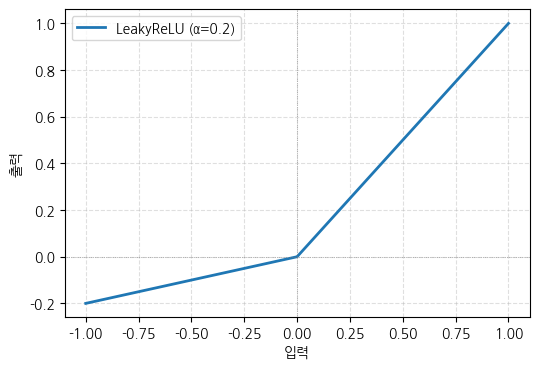

In [24]:
import torch.nn.functional as F

# LeakyReLU: 음수 구간 기울기(negative_slope) 0.01 (기본값)
viz.plot_activation_compare(
    {'LeakyReLU (α=0.2)': lambda x: F.leaky_relu(x, negative_slope=0.2)},
    x_range=(-1, 1),
    figsize=(6, 4)
)

## [코드 11-9] DCGAN 판별자 클래스

이미지를 받아 진짜일 확률(0~1)을 출력한다. 활성화 함수는 `LeakyReLU(0.2)`,
마지막 활성화는 `Sigmoid`. 첫 합성곱 블록에는 배치 정규화를 사용하지 않아
저수준 특징을 그대로 판별에 사용한다.


In [25]:
###############################################################################
# 코드 11-9 - DCGAN 판별자 클래스
###############################################################################
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # (B, 1, 28, 28) -> (B, 64, 14, 14) -> (B, 128, 7, 7)
        self.disc_conv = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),          # 판별자에는 LeakyReLU (GAN 학습 안정화)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid(),               # 0~1 (진짜일 확률에 해당)
        )

    def forward(self, x):
        h = self.disc_conv(x)
        return self.fc(h)


## [코드 11-10] DCGAN 가중치 초기화

DCGAN 논문 권장 초기화: 합성곱·역합성곱 가중치를 평균 0, 표준편차 0.02 정규
분포로, 배치 정규화 가중치(스케일)는 평균 1, 표준편차 0.02로 초기화한다.
선형 계층은 DCGAN 권장 대상이 아니므로 파이토치 기본 초기화를 사용한다.

여기서 `LATENT_DIM`은 생성자 입력 잠재 벡터 크기(100)다.


In [26]:
###############################################################################
# 코드 11-10 - DCGAN 모델의 가중치 초기화
###############################################################################
def weights_init(m):
    classname = m.__class__.__name__        # 계층 종류 구분을 위한 클래스 이름
    if 'Conv' in classname:
        # 합성곱·역합성곱 계층: 평균 0, 표준편차 0.02 정규 분포
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        # 배치 정규화 계층: 처음에는 입력을 그대로 통과시키도록 1.0
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


LATENT_DIM = 100        # 생성자 입력 잠재 벡터 크기

# 생성자와 판별자 객체 생성 및 가중치 초기화
discriminator = Discriminator().to(device)
generator = Generator(latent_dim=LATENT_DIM).to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)

common.print_param_summary({
    '생성자': generator,
    '판별자': discriminator,
})


생성자           :    1,818,753
판별자           :      138,817
학습 비율: 100.00%


## [코드 11-11] 손실 함수와 옵티마이저

이진 교차 엔트로피 손실 함수(`nn.BCELoss`)와 Adam 옵티마이저를 사용한다.
DCGAN의 Adam은 `betas=(0.5, 0.999)`를 사용해 첫 번째 값(과거 기울기 방향의
반영 비율)을 기본값 0.9 대신 0.5로 줄인다. 생성자와 판별자를 번갈아 학습해
한쪽이 최적화될 때마다 다른 쪽의 손실 지형이 달라지기 때문이다.


In [27]:
###############################################################################
# 코드 11-11 - 손실 함수와 옵티마이저
###############################################################################
import torch.optim as optim

LR = 2e-4
criterion = nn.BCELoss()
optimizer_g = optim.Adam(
    generator.parameters(), lr=LR, betas=(0.5, 0.999),
)
optimizer_d = optim.Adam(
    discriminator.parameters(), lr=LR, betas=(0.5, 0.999),
)


## [코드 11-12] DCGAN 학습 함수 - 판별자/생성자 교대 학습

판별자 학습: 진짜 이미지(데이터로더의 샘플)는 1로, 가짜 이미지(생성자 출력)는
0으로 판별하도록 학습한다. 가짜 이미지는 `.detach()`로 연산 그래프에서 분리해
생성자에 불필요한 기울기가 흘러가지 않게 한다.

생성자 학습: 판별자가 가짜 이미지를 1(진짜)로 판단하도록 속이는 것이 목표다.
`.detach()` 없이 판별자를 거쳐 생성자까지 기울기가 흐른다.


In [28]:
###############################################################################
# 코드 11-12 - DCGAN 학습 함수
###############################################################################
import torch

def train_epoch(generator, discriminator, train_loader,
                optimizer_g, optimizer_d, criterion, latent_dim, device):
    generator.train()
    discriminator.train()
    loss_d_sum = 0.0
    loss_g_sum = 0.0
    sample_size = 0
    # 데이터로더의 이미지 샘플은 모두 진짜이므로 레이블이 필요 없다.
    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # 1) 판별자 학습
        optimizer_d.zero_grad()
        # 진짜 이미지를 진짜(1)로 판별하도록 학습
        loss_d_real = criterion(discriminator(real_images), real_labels)
        # 생성자가 만든 가짜 이미지는 가짜(0)로 판별하도록 학습
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(z)
        # detach(): 판별자 학습 시 생성자 기울기가 함께 계산되지 않도록 분리
        loss_d_fake = criterion(
            discriminator(fake_images.detach()), fake_labels,
        )
        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizer_d.step()

        # 2) 생성자 학습
        optimizer_g.zero_grad()
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(z)
        # 가짜 이미지를 진짜(1)로 판단하도록 판별자를 속이는 방법을 학습
        loss_g = criterion(discriminator(fake_images), real_labels)
        loss_g.backward()
        optimizer_g.step()

        loss_d_sum += loss_d.item() * batch_size
        loss_g_sum += loss_g.item() * batch_size
        sample_size += batch_size
    return loss_d_sum / sample_size, loss_g_sum / sample_size


## 참고 - 전체 학습 루프 (검증 손실 없음, 본문 비공개)

DCGAN은 검증 손실을 계산할 정답이 없으므로 훈련 손실만 추적한다. 본문과 같이
20 에포크 학습한다. 판별자·생성자 손실이 단조 감소하지 않고 일정 범위에서
진동하는 것이 GAN 특유의 정상 학습 패턴이다.

학습 로그·전체 학습 시간·손실 곡선은 공통코드컨벤션 §7.6/§7.7에 따라
`common.EpochLogger`로 통일한다. 손실이 판별자/생성자 두 개이므로
`columns=('판별자 손실', '생성자 손실')`로 두 열을 출력한다. 다만 GAN은 두
손실이 적대적으로 경쟁해 검증 손실 기반의 "최적 에포크" 개념이 약하므로,
`log.summary()`가 보고하는 최적 에포크는 참고용이며 핵심은 **전체 학습
시간과 두 손실 곡선**(`log.plot()`)이다.


In [29]:
# 참고 - 전체 학습 루프 (검증 손실 없음, 본문 비공개 함수)
# 학습 로그·전체 학습 시간·손실 곡선은 공통코드컨벤션 §7.6/§7.7에 따라
# common.EpochLogger 로 통일한다. GAN 은 판별자/생성자 두 손실이 적대적으로
# 경쟁하므로 검증 손실이나 단조 감소하는 "최적 에포크" 개념이 약하다.
# minimize='판별자 손실'로 두지만 summary 의 최적 에포크는 참고용이며, 핵심은
# 전체 학습 시간과 두 손실 곡선이다(아래 log.plot 이 두 곡선을 함께 그린다).
EPOCHS = 20
log = common.EpochLogger(
    EPOCHS,
    columns=('판별자 손실', '생성자 손실'),
    formats=('{:.4f}', '{:.4f}'),
    minimize='판별자 손실',
    target_rows=EPOCHS
)
for epoch in range(1, EPOCHS + 1):
    loss_d, loss_g = train_epoch(
        generator, discriminator, train_loader,
        optimizer_g, optimizer_d, criterion, LATENT_DIM, device,
    )
    log.row(epoch, loss_d, loss_g)
log.summary()


epoch  판별자 손실  생성자 손실     시간
 1/20       0.6474       1.8448     0:12
 2/20       0.7174       1.6408     0:24
 3/20       0.8240       1.4411     0:35
 4/20       0.9215       1.2804     0:47
 5/20       0.9661       1.2228     0:59
 6/20       0.9873       1.1967     1:11
 7/20       0.9998       1.1909     1:22
 8/20       1.0058       1.1827     1:34
 9/20       1.0034       1.1906     1:46
10/20       1.0038       1.1966     1:57
11/20       1.0104       1.2052     2:09
12/20       1.0030       1.1964     2:21
13/20       1.0057       1.1984     2:33
14/20       1.0041       1.2037     2:44
15/20       1.0057       1.2070     2:56
16/20       1.0062       1.2220     3:07
17/20       1.0027       1.2181     3:18
18/20       1.0025       1.2224     3:30
19/20       1.0034       1.2206     3:41
20/20       0.9993       1.2215     3:52
----------------------------------------
전체 학습 시간 3:52


## 참고 - 학습 곡선 ([그림 11-10] 대응)

판별자와 생성자 손실 모두 한 배치에서 계산한 이진 교차 엔트로피 기반 값이라
한 그래프에 함께 그릴 수 있다. GAN의 학습 곡선은 단조 감소하지 않고 일정
범위에서 진동하는데, 이는 학습 실패가 아니라 두 신경망이 균형을 맞추는
정상 신호다.


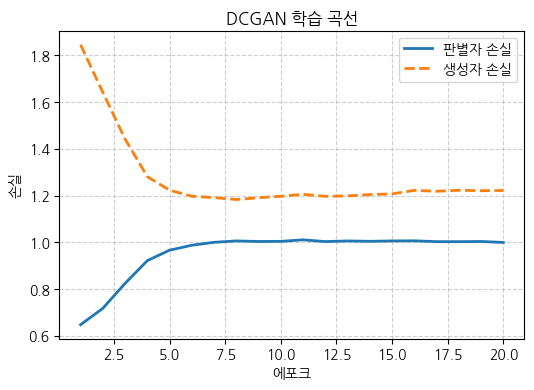

In [30]:
# 참고 - DCGAN 학습 곡선 시각화
# EpochLogger 가 보관한 두 손실 이력으로 판별자·생성자 곡선을 함께 그린다.
log.plot(title='DCGAN 학습 곡선', figsize=(6, 4))


## [코드 11-13] DCGAN 의 이미지 생성 ([그림 11-11] 대응)

학습된 생성자에 무작위 잠재 벡터를 입력해 16장의 의류 이미지를 생성한다.
`Tanh` 출력 범위 [-1, 1]을 시각화 전에 [0, 1]로 변환한다.


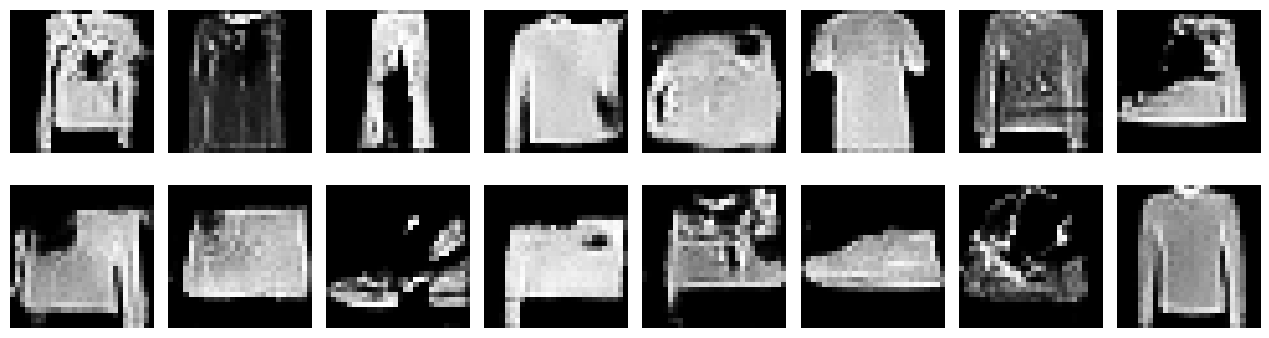

In [31]:
###############################################################################
# 코드 11-13 - DCGAN 으로 16 장의 이미지 생성
###############################################################################
z_test = torch.randn(16, LATENT_DIM).to(device)  # 무작위 잠재 벡터 16 개
generator.eval()
with torch.no_grad():
    generated = generator(z_test)
    # Tanh 출력 [-1, 1] -> 시각화용 [0, 1]
    generated = (generated + 1) / 2

viz.plot_images(
    list(generated.cpu()),
    images_per_row=8,
)


본문 [그림 11-11]처럼 다양한 형태의 의류가 생성된다. VAE 생성 결과와 비교
하면 윤곽이 더 선명하고 또렷하다. 다만 GAN은 학습 데이터 전체 분포를 학습
하므로 무작위 잠재 벡터로부터 어떤 클래스가 생성될지 미리 예측하기는 어렵다.
